In [4]:
# Importing required packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib.patches import Rectangle
import os
import chardet
import matplotlib
from matplotlib.colors import LogNorm

from IPython.display import Markdown, display
def printmd(string):
    display(Markdown(string))
    

    # File Locations
Part_A_1_file_path =f"DATA\Gross_State_Domestic_Product\GSDP.csv"
Part_A_2_DIR_path =f"DATA\GDP_SECTORS_STATES"

Part_B_file_path =f"DATA\\drop_out\\rs_session243_au570_1.1.csv"

### Part I- A:

   Business understanding :- 
   a. Identity the states having consistent growth rate and states that struggeling 
   b. Performence of Home state comparing with the national average 
   c. identify the top-5 and lower-5 performing states 
   
   Data Preparation:-
   
   GDP State wise data was downloaded from Governament open data website. and stored in folder
   <b>DATA\Gross_State_Domestic_Product </b>
   
   <br>

In [5]:
#Loading Data 

gsdp =pd.read_csv(Part_A_1_file_path)

In [6]:
# Review data
gsdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 36 columns):
Items  Description           11 non-null object
Duration                     11 non-null object
Andhra Pradesh               11 non-null float64
Arunachal Pradesh            9 non-null float64
Assam                        9 non-null float64
Bihar                        9 non-null float64
Chhattisgarh                 11 non-null float64
Goa                          9 non-null float64
Gujarat                      9 non-null float64
Haryana                      11 non-null float64
Himachal Pradesh             7 non-null float64
Jammu & Kashmir              9 non-null float64
Jharkhand                    9 non-null float64
Karnataka                    9 non-null float64
Kerala                       9 non-null float64
Madhya Pradesh               11 non-null float64
Maharashtra                  7 non-null float64
Manipur                      7 non-null float64
Meghalaya                    

#### Review:
Total Columns = 36 out of which two in object type and rest of all are in float
and there are 11 rows

<br>

In [7]:
gsdp.head()

,Items Description,Duration,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chhattisgarh,Goa,Gujarat,Haryana,...,Telangana,Tripura,Uttar Pradesh,Uttarakhand,West Bengal1,Andaman & Nicobar Islands,Chandigarh,Delhi,Puducherry,All_India GDP
0,GSDP - CURRENT PRICES (` in Crore),2011-12,379402.0,11063.0,143175.0,247144.0,158074.0,42367.0,615606.0,297539.0,...,359433.0,19208.0,724049.0,115523.0,NaN,3979.0,18768.0,343767.0,16818.0,8736039.0
1,GSDP - CURRENT PRICES (` in Crore),2012-13,411404.0,12547.0,156864.0,282368.0,177511.0,38120.0,724495.0,347032.0,...,401493.0,21663.0,822903.0,131835.0,NaN,4421.0,21609.0,391238.0,18875.0,9946636.0
2,GSDP - CURRENT PRICES (` in Crore),2013-14,464272.0,14602.0,177745.0,317101.0,206690.0,35921.0,807623.0,400662.0,...,452186.0,25593.0,944146.0,149817.0,NaN,5159.0,24787.0,443783.0,21870.0,11236635.0
3,GSDP - CURRENT PRICES (` in Crore),2014-15,526468.0,16761.0,198098.0,373920.0,234982.0,40633.0,895027.0,437462.0,...,511178.0,29667.0,1043371.0,161985.0,NaN,5721.0,27844.0,492424.0,24089.0,12433749.0
4,GSDP - CURRENT PRICES (` in Crore),2015-16,609934.0,18784.0,224234.0,413503.0,260776.0,45002.0,994316.0,485184.0,...,575631.0,NaN,1153795.0,184091.0,NaN,NaN,30304.0,551963.0,26533.0,13675331.0


#### Review

Duriation represents financial year <br>
Item description  describes the quantitavive variable description

In [8]:
gsdp[['Items  Description','Duration']]

,Items Description,Duration
0,GSDP - CURRENT PRICES (` in Crore),2011-12
1,GSDP - CURRENT PRICES (` in Crore),2012-13
2,GSDP - CURRENT PRICES (` in Crore),2013-14
3,GSDP - CURRENT PRICES (` in Crore),2014-15
4,GSDP - CURRENT PRICES (` in Crore),2015-16
5,GSDP - CURRENT PRICES (` in Crore),2016-17
6,(% Growth over previous year),2012-13
7,(% Growth over previous year),2013-14
8,(% Growth over previous year),2014-15
9,(% Growth over previous year),2015-16


#### Subsequent Analysis

    a. Removing 2016-2017 period since most of data points are not availible and as per the task instruction given
    b. Cleaned data will continue saving in clean_gsdp

In [9]:
# Deleting period related 2016-2017 as per the instuction
indexes_to_be_removed = list(gsdp[(gsdp['Duration'] == '2016-17') ].index)

clean_gsdp =  gsdp.drop(indexes_to_be_removed)
    
clean_gsdp.shape

(9, 36)

In [10]:
#observing the state wise missing values for GDP and saving in variable state_wise_empty_rows

state_wise_empty_rows = clean_gsdp.isnull().sum(axis=0)

state_wise_empty_rows[state_wise_empty_rows!=0].sort_values(ascending =False)

West Bengal1                 9
Andaman & Nicobar Islands    2
Tripura                      2
Rajasthan                    2
Punjab                       2
Nagaland                     2
Mizoram                      2
Manipur                      2
Maharashtra                  2
Himachal Pradesh             2
dtype: int64

#### Review 

    a. Based on the above table it is clear that West Bengal does't have any records
    b. remaining states having few minor missing values
    
#### Action

    a. Removing "West Bengal"  from the cleaned_gsdp

In [11]:
clean_gsdp=clean_gsdp.drop("West Bengal1",axis=1)

In [12]:
# list of remaining null values
remaining_null_period = clean_gsdp.loc[clean_gsdp.isnull().any(axis=1),clean_gsdp.isnull().any(axis=0)]
remaining_null_period.insert(0,'Items  Description',clean_gsdp.loc[remaining_null_period.index,'Items  Description'])
remaining_null_period.insert(1,'Duration',clean_gsdp.loc[remaining_null_period.index,'Duration'])
#remaining_null_period['Duration'] = clean_gsdp.loc[remaining_null_period.index,'Duration']
remaining_null_period

,Items Description,Duration,Himachal Pradesh,Maharashtra,Manipur,Mizoram,Nagaland,Punjab,Rajasthan,Tripura,Andaman & Nicobar Islands
4,GSDP - CURRENT PRICES (` in Crore),2015-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,(% Growth over previous year),2015-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Review:

    a. Based on the above table it is understanding that all 9 states or territories having missing values for the 2016-16 period
    
#### Subsequent Analysis:
    a. Since this task is not covering any ML algorithems i am not replaing these NA values. however for the purpose of mean growth these values will be ignored

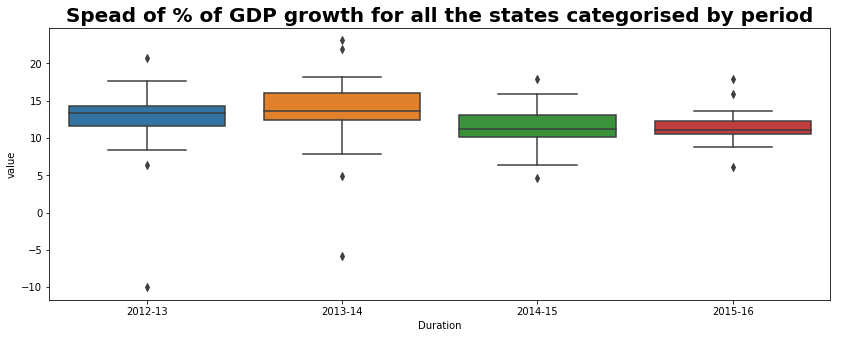

In [13]:
# Obsever the spead of GDP growuth for each period between states

unpivot_data = clean_gsdp.iloc[5:,1:-1]

unpivot_data=pd.melt(unpivot_data,id_vars=["Duration"],var_name=["States"])

plt.figure(figsize=(14, 5))
ax=sns.boxplot(x="Duration",y="value",data=unpivot_data)
ax.set_title("Spead of % of GDP growth for all the states categorised by period"
             ,fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.show()

#### Review

    a. Based on the above Boxplot it is obsrved that most of GDP growuth rates are within the same range except few states showing higher varience for the same period comparing with the other states or territories

#### Subsequent Analysis

    Review the states having higher varience in range comparsion i.e either higher than 19 or lower than 7

In [14]:
#States_having_higher_varience 

States_having_higher_varience = unpivot_data[(unpivot_data.value <=7) | 
                                             (unpivot_data.value >=19)].groupby('States').count().index

pd.concat([clean_gsdp['Duration'],clean_gsdp[States_having_higher_varience]], axis=1, sort=False)

,Duration,Goa,Jammu & Kashmir,Madhya Pradesh,Manipur,Meghalaya,Mizoram,Nagaland,Odisha
0,2011-12,42367.00,78254.00,315561.00,12915.00,19918.00,7259.0,11839.00,227872.00
1,2012-13,38120.00,87105.00,380924.00,13748.00,21872.00,8362.0,13619.00,258275.00
2,2013-14,35921.00,95893.00,437737.00,16198.00,22938.00,10293.0,16612.00,291709.00
3,2014-15,40633.00,100404.00,481982.00,18043.00,24408.00,11559.0,18414.00,321971.00
4,2015-16,45002.00,118387.00,543975.00,NaN,26745.00,NaN,NaN,341887.00
6,2012-13,-10.02,11.31,20.71,6.45,9.81,15.2,15.03,13.34
7,2013-14,-5.77,10.09,14.91,17.83,4.87,23.1,21.98,12.95
8,2014-15,13.12,4.70,10.11,11.39,6.41,12.3,10.85,10.37
9,2015-16,10.75,17.91,12.86,NaN,9.58,NaN,NaN,6.19


#### Review

   a. Based on the above table Goa Has a -ve growth rate prior to 2014
   b. Jummu & Kashimir is having lower growuth in 2014-15
   c. Madya Pradesh recorded higher growth rate in 2012-13 period 
   d. Meghalaya recorded lower rate in 2013-14
   e. North East states of [Mizoram, Nagaland,Manipur]   recorded higher growth rate in 2013-14
   g. Odisha is evident in higher growth rate in 2013-2014 and less in 2015-16
   
 #### Subsequent Analysis 
   
   since these increases showing near reality and no suspecious values found proceding furthet without altering data    
   
   <br>
   <br>
   <br>

#### Activity (1)
Calculate the average growth of states

In [15]:
# Calculated avg growth rate 
avg_growth_rate =pd.DataFrame(clean_gsdp[(clean_gsdp["Items  Description"] =="(% Growth over previous year)")
                                         & (clean_gsdp["Duration"] !="2012-13")].mean())
avg_growth_rate.columns =["Avg_Growth"]
avg_growth_rate=avg_growth_rate.sort_values("Avg_Growth",ascending=False)

state_growth_rate = avg_growth_rate[avg_growth_rate.index!="All_India GDP"]
india_growth_rate = round(avg_growth_rate[avg_growth_rate.index=="All_India GDP"].iloc[0,0],2)

# print AVG Growth rate
print(state_growth_rate)

                           Avg_Growth
Mizoram                     17.700000
Tripura                     17.030000
Nagaland                    16.415000
Manipur                     14.610000
Arunachal Pradesh           14.413333
Karnataka                   14.120000
Andhra Pradesh              14.033333
Andaman & Nicobar Islands   13.785000
Chhattisgarh                13.703333
Bihar                       13.603333
Telangana                   12.763333
Assam                       12.650000
Madhya Pradesh              12.626667
Kerala                      12.583333
Tamil Nadu                  12.336667
Himachal Pradesh            12.280000
Delhi                       12.160000
Puducherry                  12.053333
Chandigarh                  11.960000
Uttar Pradesh               11.940000
Haryana                     11.846667
Uttarakhand                 11.803333
Jharkhand                   11.500000
Rajasthan                   11.320000
Maharashtra                 11.260000
Punjab      

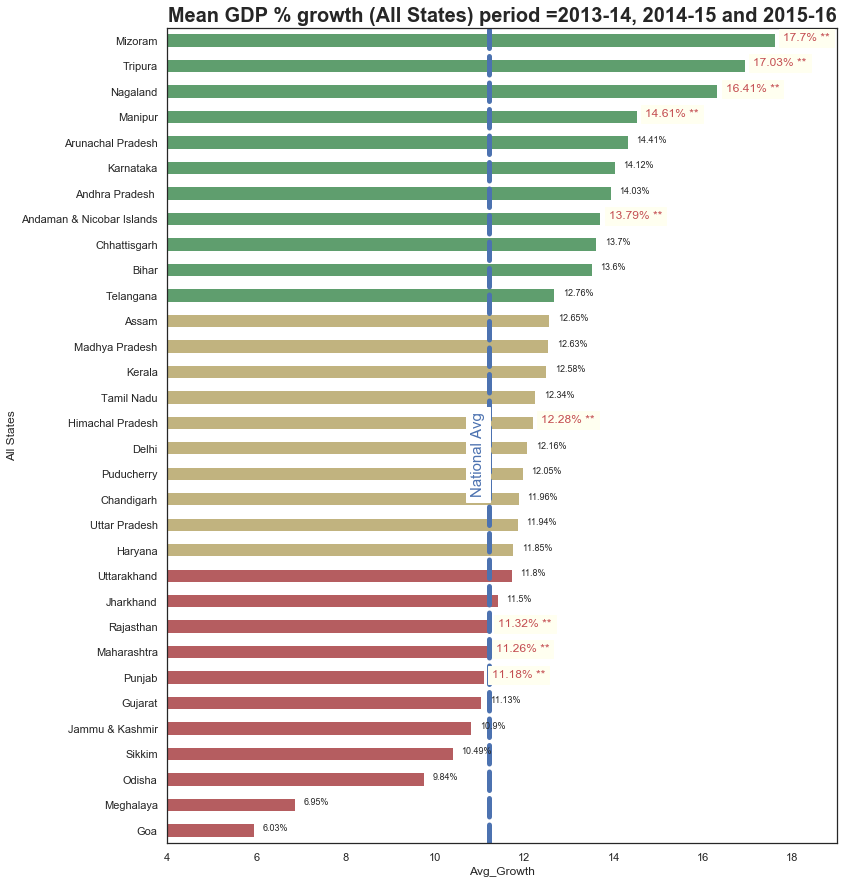

In [16]:
# compartive chart between all the staes vs GPV values missing for 2015-2016 period excluding West Bengal

# setting Plot configurations
plt.figure(figsize=(12, 15))
sns.set()
sns.set(style="white")
#palette = sns.color_palette("blues")
#palette = sns.cubehelix_palette(state_growth_rate.count(),start =0,rot=0.9)
palette=sns.color_palette(list(pd.qcut(state_growth_rate.Avg_Growth,3,labels=["r", "y", "g"])))

#iniating Bar Plot
ax=sns.barplot(x="Avg_Growth",y=state_growth_rate.index,data=state_growth_rate, palette=palette, linewidth=8)
plt.ylabel("All States")
plt.xlim(int(avg_growth_rate.min()-2),int(avg_growth_rate.max()+2))
ax.set_title("Mean GDP % growth (All States) period =2013-14, 2014-15 and 2015-16"
             ,fontdict={'fontsize': 20, 'fontweight': 'bold'})

#identify the National Average and add a verticle line with representing avg GDP
plt.axvline(x=india_growth_rate,linestyle="--",color="B",dash_capstyle="round",drawstyle="steps",
            label="National Avg",linewidth=5)
plt.text(india_growth_rate-0.4,15,'National Avg',rotation=90,color="b",backgroundcolor="W",fontsize=15)

# assigning value lables for Bar Chart ** indicates respective state has missing values for the period of 2015-2016
ind =0
for i in state_growth_rate.iterrows():
    value =round(float(i[1]),2)
    if i[0] in list(remaining_null_period.columns):
        plt.text(value+0.1,ind,r'{}% **'.format(value),fontsize=12,backgroundcolor="ivory",color="R")
    else :
          plt.text(value+0.1,ind,r'{}%'.format(value),fontsize=9)
    ind=ind+1

plt.show()

#### Review

Above graph represent Mean growth rate for the period 2013-14, 2014-15 and 2015-16 for each state
verticle line represent the National Mean for the same period
Lable with Red color represent source data missing of a GDP values for the period of 2015-16

#### Findings 

    
    a. North East states of [Mizoram,Tripura,Nagaland,Manipur,Arunachal Pradesh] are demonstrating higher % of Revenue      growth however kind of note most of these GDP values are not at availible for the period of 2015-16.
    b. following by Karnataka and Andhra Pradesh Leading 
    c. [Goa, Megalaya, Odisha, Sikkim and J&K] showing lower growth and growth rate is far lesser than National Avg 11.1

#### Activity(2)

Curiosity exercise comparing with Home State

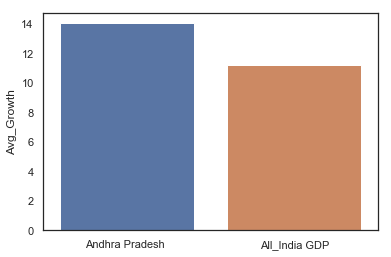

In [17]:
home_vs_national = avg_growth_rate.reindex(["Andhra Pradesh ","All_India GDP"])

sns.barplot(y="Avg_Growth",x=home_vs_national.index,data=home_vs_national)

plt.show()

#### Review 

Clearly showing my home state performence is higher than Country GDP growth %
<br>
<br>



 Staes Does't have 2015-16 performence: 

 ['Himachal Pradesh', 'Maharashtra', 'Manipur', 'Mizoram', 'Nagaland', 'Punjab', 'Rajasthan', 'Tripura', 'Andaman & Nicobar Islands']


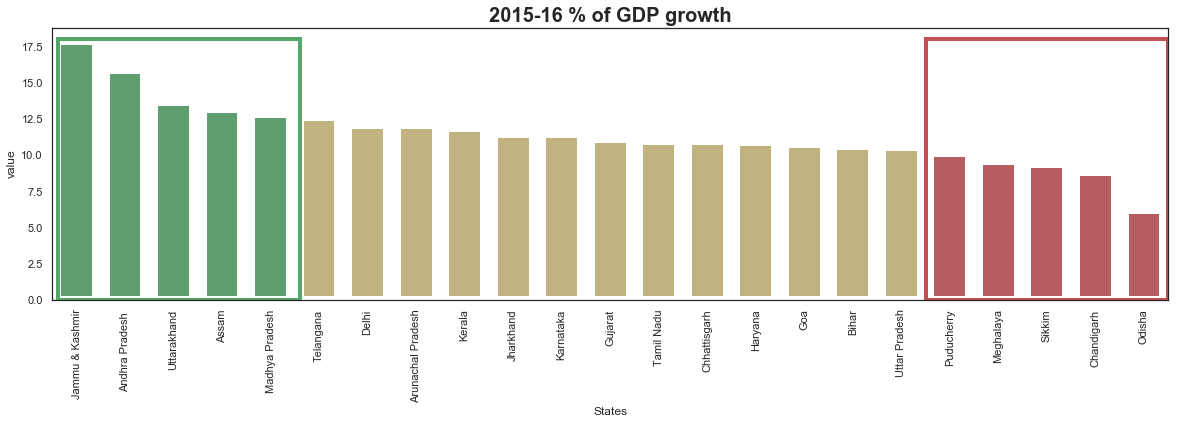

In [18]:
GDP_2015_16 = clean_gsdp[(clean_gsdp["Duration"]=="2015-16") & 
                         (clean_gsdp["Items  Description"]=="(% Growth over previous year)")].iloc[:,2:]


#re-organizing data in row wise convinence
GDP_2015_16=pd.melt(GDP_2015_16,var_name=["States"])

print("\n Staes Does't have 2015-16 performence: \n\n" , GDP_2015_16[GDP_2015_16.value.isnull()].States.tolist())

# Removing states does't have 2015-2016 GDP %

GDP_2015_16=GDP_2015_16[(GDP_2015_16.value.isnull()==False) & (GDP_2015_16.States != "All_India GDP")]
GDP_2015_16.sort_values("value",ascending=False,inplace =True) #Sorting the states ascending


# setting Plot configurations
plt.figure(figsize=(20, 5))
sns.set()
sns.set(style="white")

#Top Performer are identified as Green and Buttom and rest are all coded as yellow
_colors =["g"] * 5 + ["y"] * (GDP_2015_16.shape[0]-10) + ["r"] * 5
palette = sns.color_palette(_colors)

#palette = sns.cubehelix_palette(GDP_2015_16.shape[0],start =0.9,rot=0,reverse =True)
ax=sns.barplot(data =GDP_2015_16,x="States",y="value",palette=palette, linewidth=8 )
locs, labels = plt.xticks()
plt.setp(labels, rotation=90)
ax.set_title("2015-16 % of GDP growth",fontdict={'fontsize': 20, 'fontweight': 'bold'})

#Identifying top 5 performing states
ax.add_patch(Rectangle((-.39,0), 5, 18, facecolor="None",edgecolor='g',lw=4))

#Identifying low 5 states
ax.add_patch(Rectangle((GDP_2015_16.shape[0]-5.5,0), 5, 18, facecolor="None",edgecolor='r',lw=4))


plt.show()

In [19]:
print("Top 5 states :")
GDP_2015_16.style.hide_index()
GDP_2015_16[:5]

Top 5 states :


,States,value
9,Jammu & Kashmir,17.91
0,Andhra Pradesh,15.85
27,Uttarakhand,13.65
2,Assam,13.19
13,Madhya Pradesh,12.86


In [20]:
print("bottom 5 states :")
GDP_2015_16[-5:]

bottom 5 states :


,States,value
31,Puducherry,10.15
16,Meghalaya,9.58
22,Sikkim,9.39
29,Chandigarh,8.84
19,Odisha,6.19


#### Summary of Assignment Part -I A

Ploted graph represent Mean growth rate for the period 2013-14, 2014-15 and 2015-16 for each state verticle line represent the National Mean for the same period Lable with Red color represent source data missing of a GDP values for the period of 2015-16

    a. North East states of [Mizoram,Tripura,Nagaland,Manipur,Arunachal Pradesh] are evidenting higher % of Revenue growth. however kind of note most of these GDP values are not at availible for the period of 2015-16.
    b. following by Karnataka and Andhra Pradesh Leading 
    c. [Goa, Megalaya, Odisha, Sikkim and J&K] showing lower growth and growth rate is far lesser than National Avg 11.1



Ploted states & territories GDP growth rate for the period of 2015-16. excluded states doest have GDP growth for the same period 


    a. 2015-2016 % of GDP growth is missing for the following states 
    ['Himachal Pradesh', 'Maharashtra', 'Manipur', 'Mizoram', 'Nagaland', 'Punjab', 'Rajasthan', 'Tripura', 'Andaman & Nicobar Islands']

    b. TOP five states are 
       ['Jammu & Kashmir','Andhra Pradesh','Uttarakhand','Assam','Madhya Pradesh']
       
    c. bottom 5 states are 
       [Odisha, Chandigarh,Sikkim,Meghalaya,Puducherry]


<br>
<br>

### PART-I B

 Business understanding :- 
   Required to analyze the 2014-15 state governament GDP capita 
   Segments the states based on GDP per capital
   analyse the subssctor contributions for GDP capita 
   
   
   <br>

In [21]:
#Loading Statewise data 


filelist = os.listdir(Part_A_2_DIR_path) 

ALL_States_SectorWise=pd.DataFrame()

for i in filelist:
    filename = Part_A_2_DIR_path+"\\"+i
    encod = "utf-8"
    with open(filename, 'rb') as fi:
        rawdata =fi.read()
        encod=chardet.detect(rawdata)['encoding']
    
    data =pd.read_csv(filename,encoding = encod)
    data["State"] =i
    ALL_States_SectorWise = ALL_States_SectorWise.append(data,sort=False).copy()

print("Information is loaded for  {}".format(len(set(ALL_States_SectorWise.State))))

pd.set_option('float_format', '{:f}'.format)



Information is loaded for  30


In [22]:

ALL_States_SectorWise.describe()

,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17
count,974.000000,972.000000,973.000000,974.000000,716.000000,326.000000
mean,3508825.135524,4004637.493664,4523449.467626,5017774.039055,5659524.484038,6786961.398773
std,9896744.075457,11308481.674013,12837720.888760,14207224.192766,14278161.195002,15648157.860162
min,0.000000,0.000000,0.000000,-76.000000,0.000000,0.000000
25%,63583.250000,73639.750000,77277.000000,90396.750000,142975.250000,224902.500000
50%,445895.500000,508648.500000,570824.000000,634345.000000,893897.000000,1343266.000000
75%,2501933.500000,2816273.250000,3229811.000000,3635495.500000,4486930.000000,5689783.750000
max,127296695.000000,144846590.000000,164750647.000000,179212165.000000,121266799.000000,133876600.000000


In [23]:
ALL_States_SectorWise.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 990 entries, 0 to 32
Data columns (total 9 columns):
S.No.      990 non-null object
Item       990 non-null object
2011-12    974 non-null float64
2012-13    972 non-null float64
2013-14    973 non-null float64
2014-15    974 non-null float64
2015-16    716 non-null float64
2016-17    326 non-null float64
State      990 non-null object
dtypes: float64(6), object(3)
memory usage: 77.3+ KB


In [24]:
ALL_States_SectorWise.head()

,S.No.,Item,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,State
0,1,"Agriculture, forestry and fishing",9400805.000000,11186428.000000,12895568.000000,14819416.000000,17326726.000000,20386004.000000,NAD-Andhra_Pradesh-GSVA_cur_2016-17.csv
1,1.1,Crops,5204052.000000,6123041.000000,7114707.000000,7893514.000000,8644285.000000,9717089.000000,NAD-Andhra_Pradesh-GSVA_cur_2016-17.csv
2,1.2,Livestock,2758776.000000,3358438.000000,3643026.000000,4309078.000000,5155487.000000,5979648.000000,NAD-Andhra_Pradesh-GSVA_cur_2016-17.csv
3,1.3,Forestry and logging,250314.000000,253029.000000,280493.000000,346160.000000,340550.000000,335487.000000,NAD-Andhra_Pradesh-GSVA_cur_2016-17.csv
4,1.4,Fishing and aquaculture,1187663.000000,1451920.000000,1857342.000000,2270664.000000,3186404.000000,4353780.000000,NAD-Andhra_Pradesh-GSVA_cur_2016-17.csv


In [25]:
#extract the State Name from the file name
ALL_States_SectorWise.State =ALL_States_SectorWise.State.str.split("-").str[1]
ALL_States_SectorWise.head()

,S.No.,Item,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,State
0,1,"Agriculture, forestry and fishing",9400805.000000,11186428.000000,12895568.000000,14819416.000000,17326726.000000,20386004.000000,Andhra_Pradesh
1,1.1,Crops,5204052.000000,6123041.000000,7114707.000000,7893514.000000,8644285.000000,9717089.000000,Andhra_Pradesh
2,1.2,Livestock,2758776.000000,3358438.000000,3643026.000000,4309078.000000,5155487.000000,5979648.000000,Andhra_Pradesh
3,1.3,Forestry and logging,250314.000000,253029.000000,280493.000000,346160.000000,340550.000000,335487.000000,Andhra_Pradesh
4,1.4,Fishing and aquaculture,1187663.000000,1451920.000000,1857342.000000,2270664.000000,3186404.000000,4353780.000000,Andhra_Pradesh


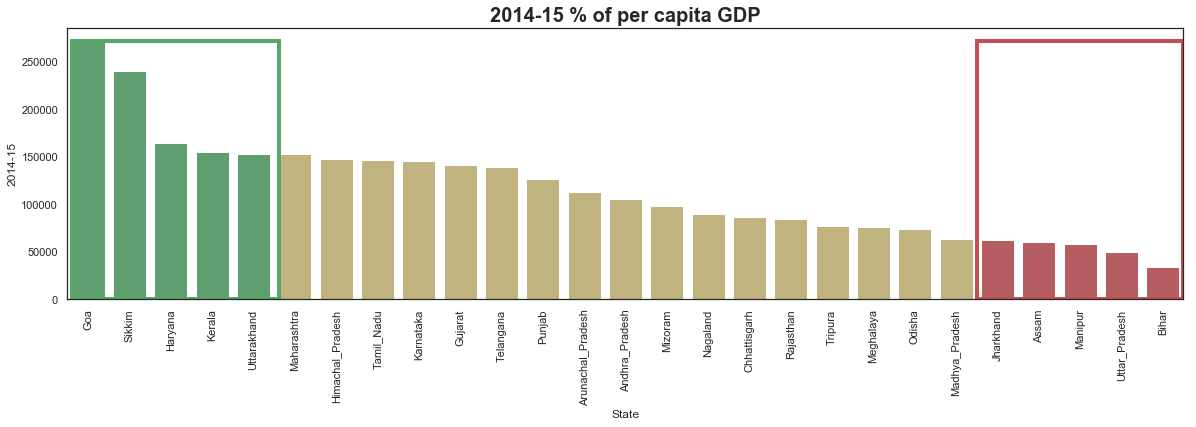

In [26]:
list_Union_Territories =['Delhi','Chandigarh','Daman','Dadra and Nagar Haveli','Lakshadweep','Andaman','Puducherry']

#filtering out union Territories, saving list into Clean_Sectorwise
Clean_Sectorwise=ALL_States_SectorWise[~ALL_States_SectorWise.State.isin(list_Union_Territories)]

#filtering GDP Per capital
GDP_per_capita_2014_15 = Clean_Sectorwise[Clean_Sectorwise["Item"]=="Per Capita GSDP (Rs.)"].loc[:,["State",'2014-15']]
GDP_per_capita_2014_15.sort_values('2014-15',ascending=False,inplace=True)


# setting Plot configurations
plt.figure(figsize=(20, 5))
sns.set()
sns.set(style="white")

_colors =["g"] * 5 + ["y"] * (GDP_per_capita_2014_15.shape[0]-10) + ["r"] * 5
palette = sns.color_palette(_colors)

ax=sns.barplot(data=GDP_per_capita_2014_15,x="State",y="2014-15",palette=palette)
locs, labels = plt.xticks()
plt.setp(labels, rotation=90)
ax.set_title("2014-15 % of per capita GDP",fontdict={'fontsize': 20, 'fontweight': 'bold'})

#Identifying top 5 performing states
ax.add_patch(Rectangle((-.39,0), 5, GDP_per_capita_2014_15["2014-15"].max(), facecolor="None",edgecolor='g',lw=4))

#Identifying low 5 states
ax.add_patch(Rectangle((GDP_per_capita_2014_15.shape[0]-5.5,0), 5, GDP_per_capita_2014_15["2014-15"].max(), 
                       facecolor="None",edgecolor='r',lw=4))

plt.show()

#### Actions 

a. Excludded Union Territories from analysis 
b. filtered only period related to 2014-15 and information related to the per captia GDP 
c. Jammu & Kashmir information for the period of 2014-15 is not availible


#### Review

a. Top - 5 Per Captia GDP states are 
    Goa
    Sikkim 
    Haryana
    Kerala
    Utarakhand
    
b. Botton 5 Per Capita GDP states are 
    Bihar 
    Uttar Pradesh
    Manipur
    Assam 
    Jarkhand 

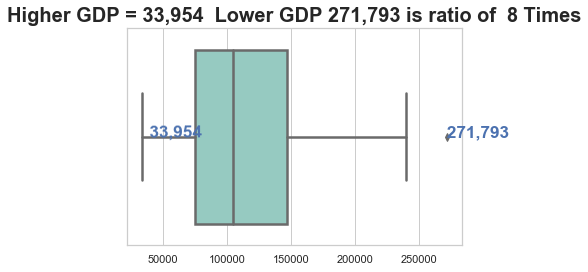

In [27]:
# Finding the ratio of highest per capital GDP to the lower per capita GDP
print("\n")

#sns.barplot([GDP_per_capita_2014_15["2014-15"].max(),GDP_per_capita_2014_15["2014-15"].min()])
sns.set(context='notebook', style='whitegrid')
ax=sns.boxplot([GDP_per_capita_2014_15["2014-15"]],color="r",linewidth=2.5,palette="Set3")
minmum = GDP_per_capita_2014_15["2014-15"].min()
maximum = GDP_per_capita_2014_15["2014-15"].max()

title =  "Higher GDP = {:2,.0f}  Lower GDP {:2,.0f} is ratio of {:2,.0f} Times".format(minmum,maximum,round(maximum/minmum))

ax.set_title(title,fontdict={'fontsize': 20, 'fontweight': 'bold'})

ax.text(minmum + 0.03,0,'{:20,.0f}'.format(minmum),horizontalalignment='center', 
        size='x-large', color='B', weight='semibold',rotation=0.3)

ax.text(maximum,0,'{:20,.0f}'.format(maximum),horizontalalignment='center', size='x-large', color='B', weight='semibold')
#ax.text(maximum - 1000,0,maximum,horizontalalignment='center', size='x-large', color='B', weight='semibold')

plt.show()


#### Review

Highest Per Capita GDP is generated by Goa of Rs 271,793
Bihar is having lower capita GDP of Rs 33,954

<b> That means Goa Per capita GPD is 8 times higher than Bihar</b>
    
however above graph also illustrate that 50% of states is having per capita GDP between 75k and 140k

#### Subsequent Analysis (2)
Analyse the primary, secondary and tertiary to the all the states GDP
however as obsevred state wise GDP also contain the items related Taxes on Products and Subsidies on products. we required to add this excess difference to the Other's section.

In [28]:
#Finding the sector wise and state wise 
state_sector=Clean_Sectorwise.loc[Clean_Sectorwise['S.No.'] =="Total",
                                  ["Item","State","2014-15"]].pivot(index="State",columns="Item")

#sorting and dropinng extra level came from pivot table 
state_sector.columns= state_sector.columns.droplevel()
state_sector.sort_index(inplace =True)

#calculating GDP came from other sources is Total DGP - sum of primary + Secondary + Tertiary
GDP_states =pd.DataFrame( Clean_Sectorwise[Clean_Sectorwise.Item=="Gross State Domestic Product"].
                         groupby("State")["2014-15"].sum())
GDP_states.columns =["Total"]

#prepare one data set
state_sector=state_sector.join(GDP_states,how="inner")
state_sector["Others"] = state_sector["Total"]-(state_sector["Primary"]+state_sector["Secondary"]+state_sector["Tertiary"])
state_sector=state_sector[["Primary","Secondary","Tertiary","Others","Total"]]

state_sector.head()

,Primary,Secondary,Tertiary,Others,Total
State,,,,,
Andhra_Pradesh,16303716.000000,10488884.000000,22032942.000000,3821300.000000,52646842.000000
Arunachal_Pradesh,716959.000000,287489.000000,631844.000000,39827.000000,1676119.000000
Assam,5326697.000000,4033091.000000,9307109.000000,1142903.000000,19809800.000000
Bihar,8019997.000000,5984896.000000,22179969.000000,1207126.000000,37391988.000000
Chhattisgarh,6400817.000000,8238886.000000,7588778.000000,1269699.000000,23498180.000000


#### Review 

Data is arranged in statewise and sector wise GDP. 


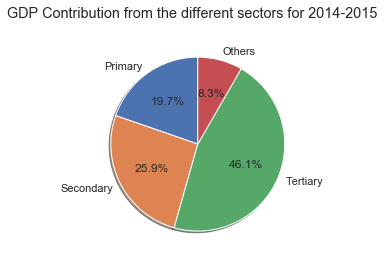

In [29]:
#Pyplot settings
fig = plt.figure()
_sector=pd.DataFrame(state_sector.sum()[:-1])

ax=plt.pie(_sector,labels=_sector.index,autopct='%1.1f%%',shadow=True, startangle=90)
fig.suptitle ("GDP Contribution from the different sectors for 2014-2015",fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.show()

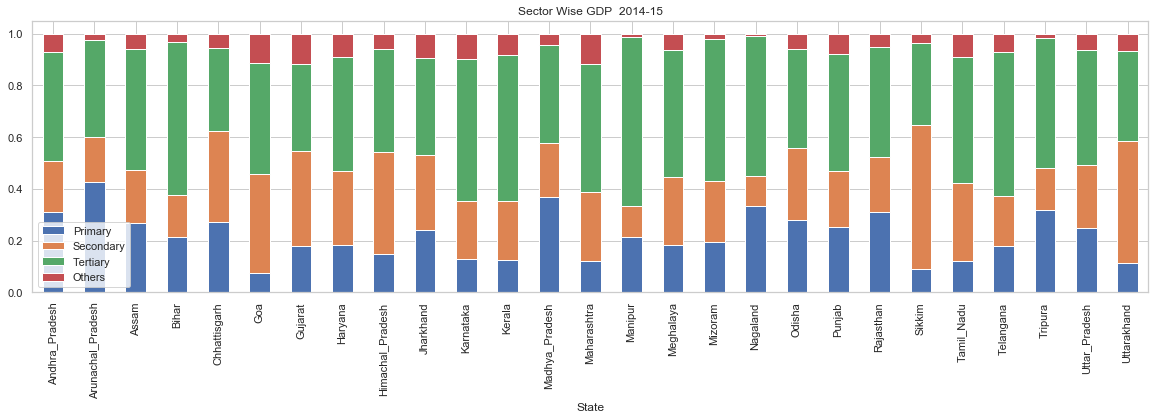

In [30]:
#Transformation and Data Preparation
_state_sector = state_sector.copy()
_state_sector.Primary = _state_sector.Primary/ _state_sector.Total
_state_sector.Secondary = _state_sector.Secondary/ _state_sector.Total
_state_sector.Tertiary = _state_sector.Tertiary/ _state_sector.Total
_state_sector.Others = _state_sector.Others/ _state_sector.Total
_state_sector = _state_sector.iloc[:,:-1]

_state_sector.plot(kind="bar",stacked=True,figsize=(20,5),title="Sector Wise GDP  2014-15")

plt.show()

#### Review

above two visual represents major contribution is came from Tertiary however both primary and secondary together approximatly about 46% of GDP.

Arunal chal pradesha and Madyapradesh states showing cleaerly higher productivity comming from the primary Sector of about 40%.

Manipur maximum productity comming from the Tertiary services.

In [31]:
#preparing the data Cleaning activity for review sub category &   GDP per capitia categorisation
GDP_per_capita_2014_15["category"] =pd.qcut(GDP_per_capita_2014_15["2014-15"],
                                            q=[0,0.20,0.5, 0.85, 1],labels=["C4","C3","C2","C1"])

#Temp Varibales with the list of indexes and retrive all sub category names
_i = [str(i) for i in np.arange(12)]
subsectors =set(Clean_Sectorwise[Clean_Sectorwise["S.No."].isin(_i)].Item)

#select all sub category names including Manipur
Cleaned_sub_sectors =Clean_Sectorwise[Clean_Sectorwise.Item.isin(subsectors)][["State","Item","2014-15"]]


#adding segmentd state category based on GDP per Capita 
Cleaned_sub_sectors=pd.merge(Cleaned_sub_sectors,GDP_per_capita_2014_15[["State","category"]],how="inner",on="State")

In [32]:
#Preparing States Master 
states = GDP_per_capita_2014_15.copy()
states.columns =["State","GDP_per_capita","category"]

#obtaining population
_population = Clean_Sectorwise[Clean_Sectorwise.Item.str.startswith("Population")][["State","2014-15"]]

#obtaining Total GDP
_gsdp_total = Clean_Sectorwise.loc[Clean_Sectorwise.Item=="Gross State Domestic Product",["State","2014-15"]]
_gsdp_total.columns =["State","gsdp_2014_15"]


#Merging 
_population.columns = ["State","Population"]
states =states.merge(_population,how="inner",on="State")
states =states.merge(_gsdp_total,how="inner",on="State")

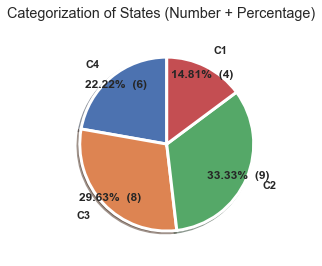

In [33]:
_i=Cleaned_sub_sectors.groupby("category")["State"].nunique()

fig = plt.figure()
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.2f}%  ({v:d})'.format(p=pct,v=val)
    return my_autopct

ax1=plt.pie(_i,labels=_i.index,autopct=make_autopct(_i),shadow=True, startangle=90,pctdistance=0.9, labeldistance=1.2,wedgeprops={'linewidth': 3},
           textprops={'weight':'bold'})
fig.suptitle ("Categorization of States (Number + Percentage)",fontdict={'fontsize': 20, 'fontweight': 'bold'})
plt.show()

#### Sectors contribution to the GDP (C1 Represent High capitia segment and C4 represent Low 


** Blue line Represent 80% of GDP per segment **

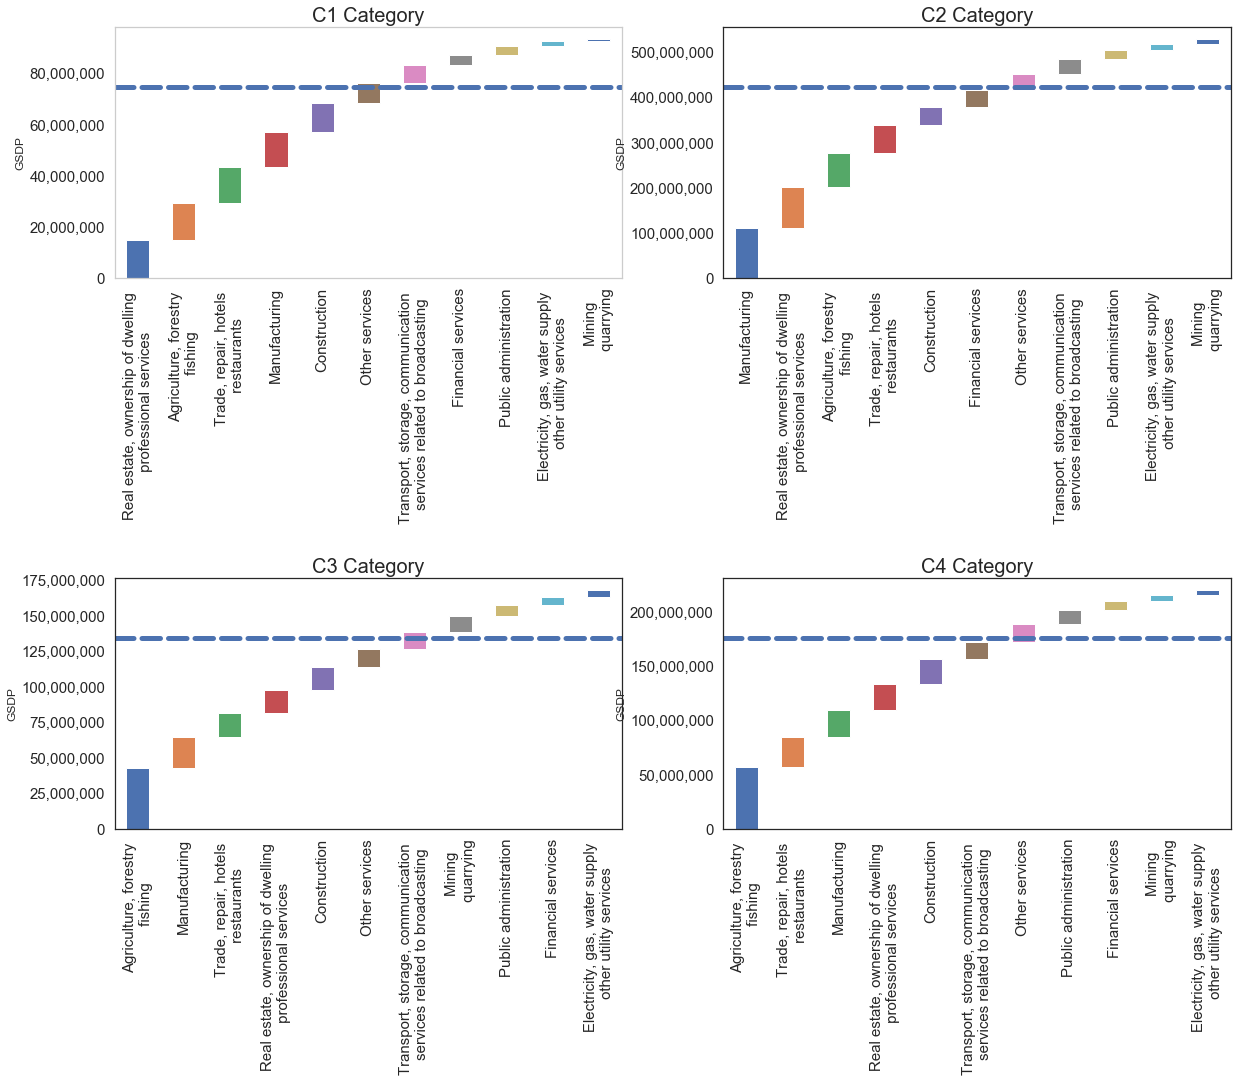

In [34]:
_group_cat_Subsector = Cleaned_sub_sectors.groupby(["category","Item"])["2014-15"].sum()
#sns.set(font_scale = 2)

#sns.set_context("paper", rc={"font.size":10,"axes.titlesize":12,"axes.labelsize":20})  
#_data =pd.DataFrame(_group_cat_Subsector["C4"]).sort_values(by="2014-15", ascending =False)

def generateGraph_fill(_cat,loc) :
    plt.subplot(4,2,loc)
    _data =pd.DataFrame(_group_cat_Subsector[_cat]).sort_values(by="2014-15", ascending =False)
    
    _data["Bottom"] = _data.cumsum().shift(1).fillna(0)
    sns.set(style="white")
    del _data.index.name 
    _data.index=_data.index.str.replace("and","\n").str.replace("&","\n")
    ax=_data["2014-15"].plot(kind="bar",bottom=_data["Bottom"] )
    ax.get_yaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    plt.ylabel("GSDP")
    ax.tick_params(labelsize=15)      
    plt.title(_cat+ " Category",fontsize=20)
    
    _tot_80per = (_data["2014-15"].sum())*0.8
    
    plt.axhline(y=_tot_80per,linestyle="--",color="B",dash_capstyle="round",drawstyle="steps",
            label="National Avg",linewidth=5)
    #plt.text(_tot_80per-0.4,15,'National Avg',rotation=90,color="b",backgroundcolor="W",fontsize=15)

print("\n")
printmd("#### Sectors contribution to the GDP (C1 Represent High capitia segment and C4 represent Low \n")
printmd("** Blue line Represent 80% of GDP per segment **")


plt.figure(figsize=(20, 35))
generateGraph_fill("C1",1)
generateGraph_fill("C2",2)
generateGraph_fill("C3",3)
generateGraph_fill("C4",4)
plt.subplots_adjust(hspace =1.2)
plt.show()

In [35]:
from IPython.display import Markdown, display
def printmd(string):
    display(Markdown(string))

printmd("## ---------- Contribution of the sub-sectors for each segment of Categories ----")

def printTextSumamry(_cat):
    printmd("\n**Following Category {} contributed to achieve 80% of Total GDP**".format(_cat))
    #printing states belongs to Category
    _states_list = ", ".join(GDP_per_capita_2014_15[GDP_per_capita_2014_15.category==_cat].State)
    printmd("*"+_states_list+"*")
    
    
    _data =pd.DataFrame(_group_cat_Subsector[_cat]).sort_values(by="2014-15", ascending =False)
    _data["CUM_SUM_per"]= round(100*_data["2014-15"].cumsum() /  _data["2014-15"].sum(),2)
    list_of_sub_sectors = list(_data[~ (_data.CUM_SUM_per >79 )].index)
    
    #printing contribution list
    for i in range(0,len(list_of_sub_sectors)):
        print(f"    {i+1}. {list_of_sub_sectors[i]}")
        
    
printTextSumamry("C1")
printTextSumamry("C2")
printTextSumamry("C3")
printTextSumamry("C4")
        

## ---------- Contribution of the sub-sectors for each segment of Categories ----


**Following Category C1 contributed to achieve 80% of Total GDP**

*Goa, Sikkim, Haryana, Kerala*

    1. Real estate, ownership of dwelling & professional services
    2. Agriculture, forestry and fishing
    3. Trade, repair, hotels and restaurants
    4. Manufacturing
    5. Construction



**Following Category C2 contributed to achieve 80% of Total GDP**

...

*Andhra_Pradesh, Mizoram, Nagaland, Chhattisgarh, Rajasthan, Tripura, Meghalaya, Odisha*

    1. Agriculture, forestry and fishing
    2. Manufacturing
    3. Trade, repair, hotels and restaurants
    4. Real estate, ownership of dwelling & professional services
    5. Construction
    6. Other services



**Following Category C4 contributed to achieve 80% of Total GDP**

*Madhya_Pradesh, Jharkhand, Assam, Manipur, Uttar_Pradesh, Bihar*

    1. Agriculture, forestry and fishing
    2. Trade, repair, hotels and restaurants
    3. Manufacturing
    4. Real estate, ownership of dwelling & professional services
    5. Construction
    6. Transport, storage, communication & services related to broadcasting


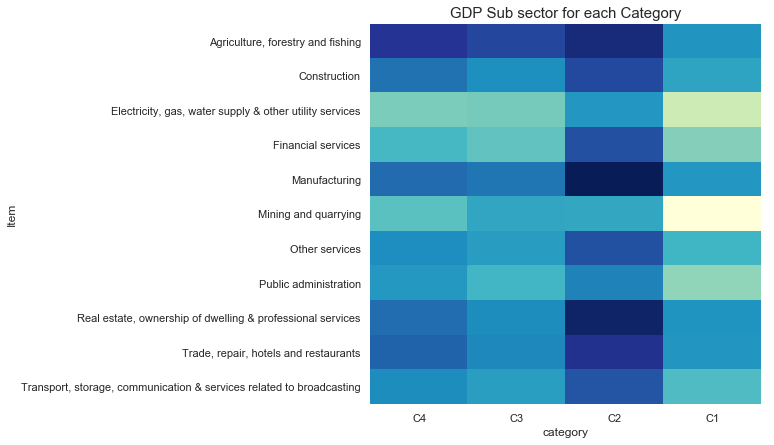

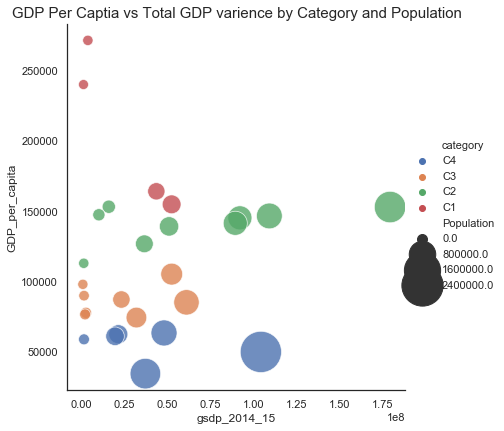

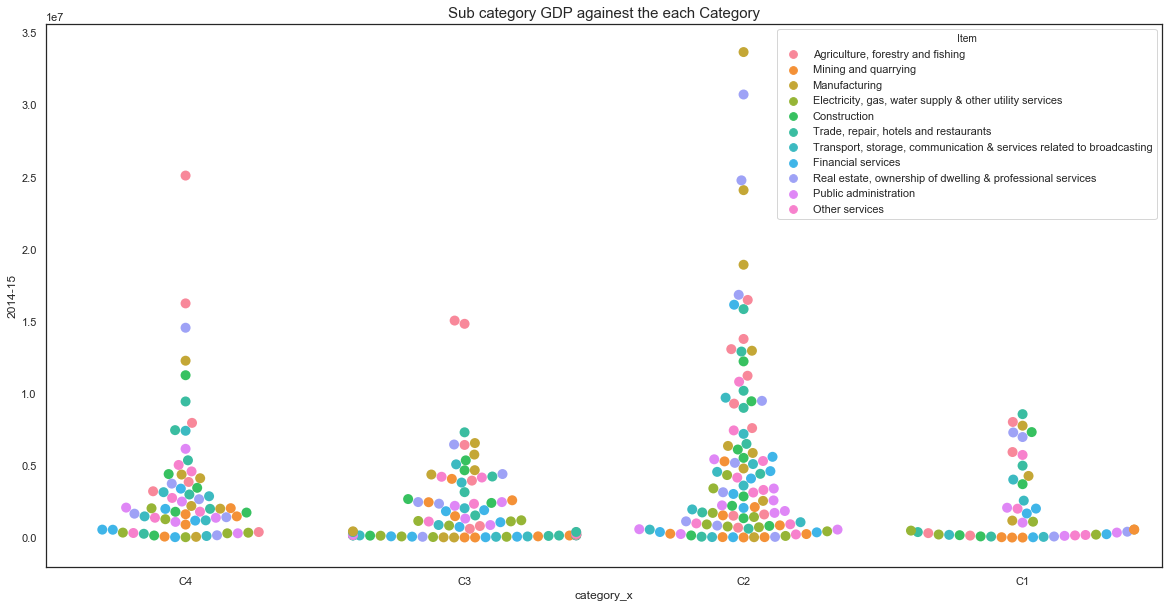

In [36]:
#Cleaned_sub_sectors[["Item","category","2014-15"]] .pivot(index="category",columns="Item").sum()
plt.figure(figsize=(7, 7))
_comparsion = pd.pivot_table(Cleaned_sub_sectors, values='2014-15', index='Item', columns='category', aggfunc='sum')

_comparsion

#Cleaned_sub_sectors
#index="State",columns="Item"
#_comparsion
sns.heatmap(_comparsion, cmap="YlGnBu",cbar =False,norm=LogNorm(vmin=Cleaned_sub_sectors["2014-15"].min(), 
                                                                vmax=Cleaned_sub_sectors["2014-15"].max()))
plt.title("GDP Sub sector for each Category",fontsize=15)
plt.show()




sns.relplot(x="gsdp_2014_15", y="GDP_per_capita", hue="category",sizes=(100, 1700), alpha=.8,size = "Population",
            height=6, data=states)
plt.title("GDP Per Captia vs Total GDP varience by Category and Population",fontsize =15)
plt.show()


_temp = Cleaned_sub_sectors.merge(states,how="inner",on="State")
plt.figure(figsize=(20,10))
g=sns.swarmplot(x="category_x",y="2014-15",data=_temp,hue="Item",dodge=False,size=10)
plt.title("Sub category GDP againest the each Category",fontsize =15)
plt.show()


## Summary assignment Part - 1 -B

**Category C1**

<b>Goa, Sikkim, Haryana, Kerala</b> states  forming under this segment of C1 (i.e Generating higher Per capita GDP). Even It is showing as GSDP per Capita is high in reality population of these states are low comparing with other states.

    a. Required to focused in identify the natural minerals which can boost Mining industry and excel the leading Manufacturing and Construction
    b. Create a facilities to for easy doing business which will relatively boost the population and create agility to grow supporting sectors such as Finance , Utility services such as (Electricity, Gas . etc) and improves trade

    
**Category C2**

<b> Uttarakhand, Maharashtra, Himachal_Pradesh, Tamil_Nadu, Karnataka, Gujarat, Telangana, Punjab, Arunachal_Pradesh</b> are the states forming under this segment. out of which 4 states are having higher population and these gross sector productivity relatively in absolute value is higher than remaining categories.

    a. Concentrate in developing support sector's such as Transportation and communication and public services sector
    b. Required to concentrate upon tourism which can increase the Trade opportunities
    
**Category C3**

<b>Andhra_Pradesh, Mizoram, Nagaland, Chhattisgarh, Rajasthan, Tripura, Meghalaya, Odisha</b> are the states forming under this segment. majorly all the states are having lower population and most of all sector's productivity is all near to the same range.

    a. Required to concentrate on developing real-estate sector 
    b. Required to concentrate Manufacturing industry even it is second largest for this segment comparing with the segment-C2 productivity is low
    
**Category C4**
  
<b>Madhya_Pradesh, Jharkhand, Assam, Manipur, Uttar_Pradesh, Bihar</b> are the states forming under this segment except Uttar Pradesh, Bihar remaining all states population.

       a. Required to concentrate on developing education which can contribute in boosting Utility and service sector productivity 
       b. By developing the education productivity in financial services will also grow 


<br>
<br>
<br>

## Section Part -II

Interpretting Drop-out rates in relation with the GDP

In [37]:
drop_out =pd.read_csv(Part_B_file_path)


print(drop_out.info())
drop_out.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 14 columns):
Sl. No.                         37 non-null object
Level of Education - State      37 non-null object
Primary - 2012-2013             29 non-null float64
Primary - 2014-2015             33 non-null float64
Primary - 2014-2015.1           31 non-null float64
Upper Primary - 2012-2013       31 non-null float64
Upper Primary - 2013-2014       35 non-null float64
Upper Primary - 2014-2015       35 non-null float64
Secondary - 2012-2013           34 non-null float64
Secondary - 2013-2014           36 non-null float64
Secondary - 2014-2015           36 non-null float64
Senior Secondary - 2012-2013    24 non-null float64
Senior Secondary - 2013-2014    27 non-null float64
Senior Secondary - 2014-2015    28 non-null float64
dtypes: float64(12), object(2)
memory usage: 4.1+ KB
None


,Sl. No.,Level of Education - State,Primary - 2012-2013,Primary - 2014-2015,Primary - 2014-2015.1,Upper Primary - 2012-2013,Upper Primary - 2013-2014,Upper Primary - 2014-2015,Secondary - 2012-2013,Secondary - 2013-2014,Secondary - 2014-2015,Senior Secondary - 2012-2013,Senior Secondary - 2013-2014,Senior Secondary - 2014-2015
0,1,A & N Islands,0.680000,1.210000,0.510000,1.230000,0.510000,1.690000,5.560000,7.200000,9.870000,14.140000,15.870000,16.930000
1,2,Andhra Pradesh,3.180000,4.350000,6.720000,3.360000,3.780000,5.200000,12.720000,12.650000,15.710000,0.350000,11.790000,nan
2,3,Arunachal Pradesh,15.160000,10.890000,10.820000,7.470000,5.590000,6.710000,12.930000,14.490000,17.110000,5.110000,17.070000,18.420000
3,4,Assam,6.240000,7.440000,15.360000,7.200000,7.050000,10.510000,26.770000,30.430000,27.060000,4.690000,7.240000,nan
4,5,Bihar,nan,2.090000,nan,nan,2.980000,4.080000,30.140000,25.330000,25.900000,nan,nan,nan


### Observation's

Data Cleaning After Observibg the data set, it is looks like column represented in original data set Primary - 2014-2015 
may be related to the 2013-14 period because all other subseqent columns are in this order. therefore we are excluding first column of "Primary - 2014-2015" and convert "Primary - 2014-2015.1 " this one for 2014-15

and objective is to identify the relationship between Primary,Upper Primary and Secondary therefore all remaining columns are excluded from the selection


In [38]:
#Identifying NA values
cleaned_drop_out = drop_out[["Level of Education - State","Primary - 2014-2015.1","Upper Primary - 2014-2015",
          "Secondary - 2014-2015"]].copy()

cleaned_drop_out.columns =["State","Primary","Upper Primary","Secondary"]

cleaned_drop_out[cleaned_drop_out.isnull().sum(axis =1)>=1]

,State,Primary,Upper Primary,Secondary
4,Bihar,nan,4.080000,25.900000
5,Chandigarh,nan,0.440000,nan
9,Delhi,nan,0.760000,11.810000
17,Kerala,nan,nan,12.320000
18,Lakshadweep,nan,2.780000,6.763000
30,Tamil Nadu,nan,nan,8.100000


In [39]:
#See the potentials to replace missing values with the previous period
drop_out[drop_out["Level of Education - State"].isin(cleaned_drop_out[cleaned_drop_out.isnull().sum(axis =1)>=1].State)]

,Sl. No.,Level of Education - State,Primary - 2012-2013,Primary - 2014-2015,Primary - 2014-2015.1,Upper Primary - 2012-2013,Upper Primary - 2013-2014,Upper Primary - 2014-2015,Secondary - 2012-2013,Secondary - 2013-2014,Secondary - 2014-2015,Senior Secondary - 2012-2013,Senior Secondary - 2013-2014,Senior Secondary - 2014-2015
4,5,Bihar,nan,2.090000,nan,nan,2.980000,4.080000,30.140000,25.330000,25.900000,nan,nan,nan
5,6,Chandigarh,nan,nan,nan,0.100000,1.080000,0.440000,nan,nan,nan,13.650000,11.280000,10.550000
9,10,Delhi,nan,nan,nan,nan,2.780000,0.760000,5.320000,8.900000,11.810000,14.470000,16.250000,17.320000
17,18,Kerala,nan,nan,nan,nan,nan,nan,9.450000,14.460000,12.320000,nan,6.400000,0.470000
18,19,Lakshadweep,2.500000,nan,nan,0.290000,1.860000,2.780000,7.680000,8.030000,6.763000,6.590000,2.820000,3.120000
30,31,Tamil Nadu,4.060000,0.460000,nan,1.240000,4.520000,nan,10.200000,12.200000,8.100000,1.870000,4.440000,3.410000


#### Observation 

6 States are having missing values. and noted that all these states are having missing records in Primary section looked into the details for these states if we can replace with the another period. however it is observed that most of all having missing Primary education for the remaining period also. so decided to drop missing values and go forowrd

In [40]:
#Since Maximum Previous values are also emtry for thes states, decided drop these states from analysis
cleaned_drop_out.drop(cleaned_drop_out[cleaned_drop_out.isnull().sum(axis =1)>=1].index,inplace =True)
cleaned_drop_out.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 31 entries, 0 to 36
Data columns (total 4 columns):
State            31 non-null object
Primary          31 non-null float64
Upper Primary    31 non-null float64
Secondary        31 non-null float64
dtypes: float64(3), object(1)
memory usage: 1.2+ KB


In [41]:
#verifying Naming conevntions differences between Drop out Data set vs SGDP Data Set
cleaned_drop_out.State = cleaned_drop_out.State.str.replace(" ","_")

#cleaned_drop_out
set(cleaned_drop_out.State ) -set(pd.merge(cleaned_drop_out,states,on="State",how="inner").State)

{'A_&_N_Islands',
 'All_India',
 'Chhatisgarh',
 'Dadra_&_Nagar_Haveli',
 'Daman_&_Diu',
 'Jammu_and_Kashmir',
 'Puducherry',
 'Uttrakhand',
 'West_Bengal'}

In [42]:
# Replaced proper names in Drop out data set with the state names collected from SGDP data Set
cleaned_drop_out.loc[cleaned_drop_out.State== "Chhatisgarh","State"]  = "Chhattisgarh"
cleaned_drop_out.loc[cleaned_drop_out.State== "Uttrakhand","State"]    = "Uttarakhand"

In [43]:
#Verifying still how many states are having information in Dropout Data set and not availible in SGDP data Set
set(cleaned_drop_out.State ) -set(pd.merge(cleaned_drop_out,states,on="State",how="inner").State)

{'A_&_N_Islands',
 'All_India',
 'Dadra_&_Nagar_Haveli',
 'Daman_&_Diu',
 'Jammu_and_Kashmir',
 'Puducherry',
 'West_Bengal'}

#### Cleaed data set by adjusting the state names for the new data set

In [44]:
#Prepared final Data Set containing the state, drop out rate along with the per capita GDP and total GDP
cleaned_drop_out["tot_early_dropout"] = cleaned_drop_out[["Primary","Upper Primary","Secondary"]].sum(axis=1)
cleaned_drop_out["Primary_all"] = cleaned_drop_out[["Primary","Upper Primary"]].sum(axis=1)
Final_States=pd.merge(cleaned_drop_out,states,on="State",how="inner")
Final_States = Final_States[["State","Primary","Upper Primary","Secondary","tot_early_dropout",
                           "Primary_all","GDP_per_capita","category"]]

In [45]:
Final_States.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24 entries, 0 to 23
Data columns (total 8 columns):
State                24 non-null object
Primary              24 non-null float64
Upper Primary        24 non-null float64
Secondary            24 non-null float64
tot_early_dropout    24 non-null float64
Primary_all          24 non-null float64
GDP_per_capita       24 non-null float64
category             24 non-null category
dtypes: category(1), float64(6), object(1)
memory usage: 1.7+ KB


In [46]:
Final_States.head()

,State,Primary,Upper Primary,Secondary,tot_early_dropout,Primary_all,GDP_per_capita,category
0,Andhra_Pradesh,6.720000,5.200000,15.710000,27.630000,11.920000,104977.000000,C3
1,Arunachal_Pradesh,10.820000,6.710000,17.110000,34.640000,17.530000,112718.000000,C2
2,Assam,15.360000,10.510000,27.060000,52.930000,25.870000,60621.000000,C4
3,Chhattisgarh,2.910000,5.850000,21.260000,30.020000,8.760000,86860.000000,C3
4,Goa,0.730000,0.070000,11.150000,11.950000,0.800000,271793.000000,C1


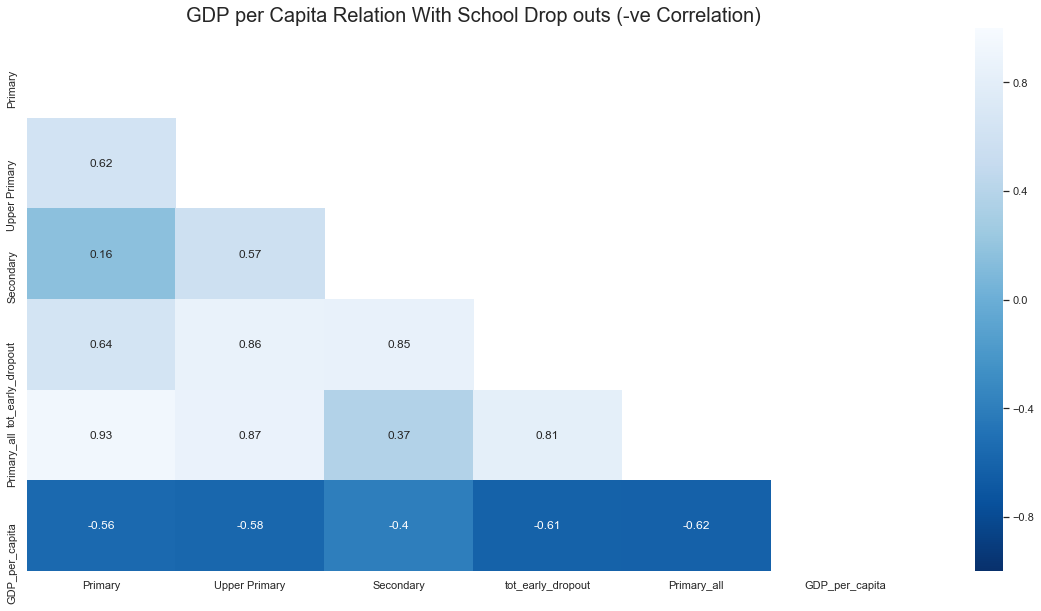

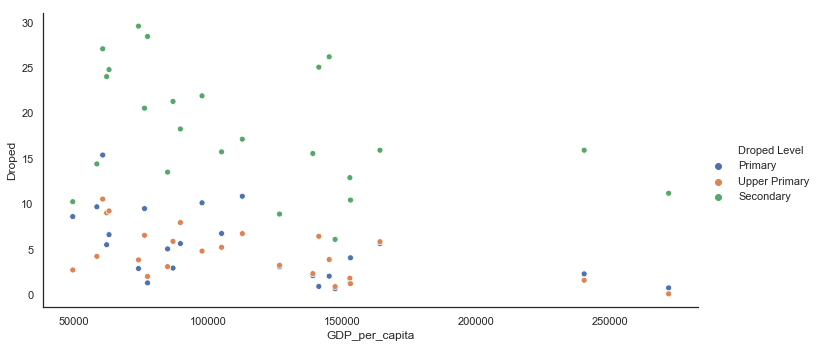

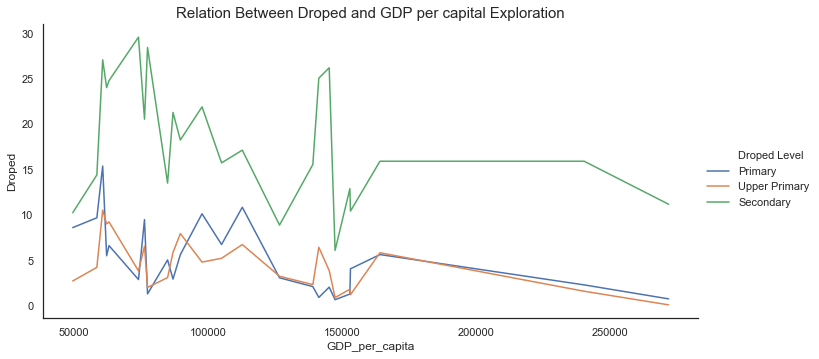

In [47]:
#Illustrating Corr between School Drop outs and GDP per captia in histogram and using Correlation matrix

_corration = Final_States.corr()
mask = np.zeros_like(_corration, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(20,10))
sns.heatmap(_corration,cmap="Blues_r",annot=True,vmin=-1,mask=mask)
plt.title("GDP per Capita Relation With School Drop outs (-ve Correlation)",fontsize=20)
plt.show()

_temp=pd.melt(Final_States[["State","Primary","Upper Primary","Secondary"]],id_vars = "State")#
_temp.columns= ["State","Droped Level","Droped"]

_temp=_temp.merge(Final_States[["State","GDP_per_capita"]],on="State",how="inner")


sns.relplot(x="GDP_per_capita",y="Droped",hue="Droped Level",data=_temp,kind  ="scatter",height=5, aspect=2)
plt.show()
sns.relplot(x="GDP_per_capita",y="Droped",hue="Droped Level",data=_temp,kind  ="line",height=5, aspect=2)

plt.title("Relation Between Droped and GDP per capital Exploration",fontsize=15)
plt.show()

#### Review


Above groaphs represent moderate -ve correlation between early education (primary + Upper Primary together) however if we noticed in relplot states are having GDEP per captia above 200k Crores are far away from the remaining states. potentially these states may effecet correlation to validate that i am going to observe the states majorly spead with the GDP per captia lower that 150k.  

In [48]:
#Higher Gdp per capita  

Final_States[Final_States.GDP_per_capita>200000]

,State,Primary,Upper Primary,Secondary,tot_early_dropout,Primary_all,GDP_per_capita,category
4,Goa,0.730000,0.070000,11.150000,11.950000,0.800000,271793.000000,C1
19,Sikkim,2.270000,1.570000,15.890000,19.730000,3.840000,240274.000000,C1


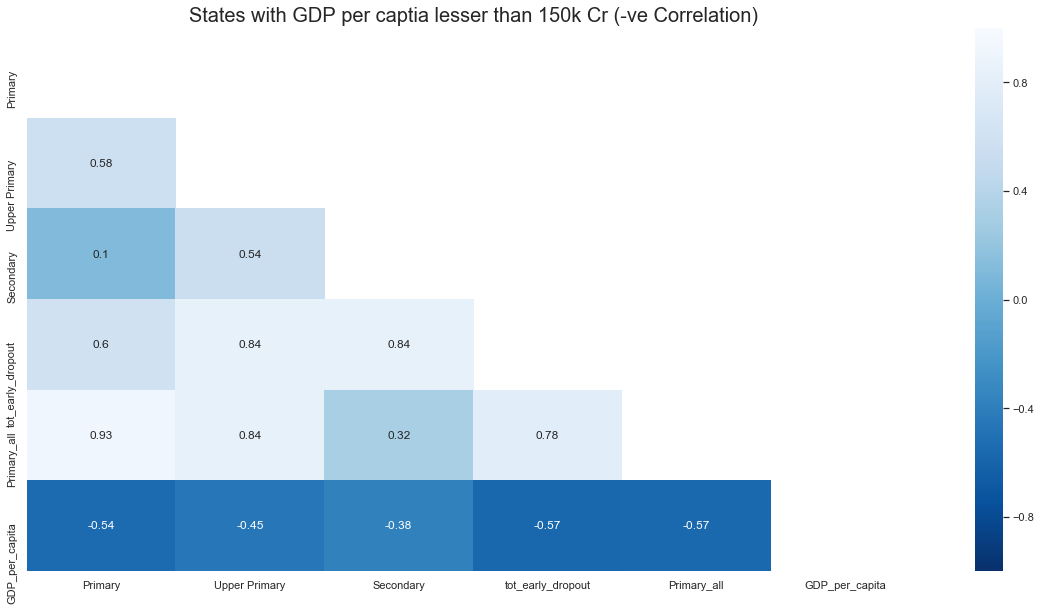

In [50]:


_corration_substates = Final_States[Final_States.GDP_per_capita<200000].corr()

plt.figure(figsize=(20,10))
sns.heatmap(_corration_substates,cmap="Blues_r",annot=True,vmin=-1,mask=mask)
plt.title("States with GDP per captia lesser than 150k Cr (-ve Correlation)",fontsize=20)
plt.show()

### Sumamry Part-II 

Observed that -ve moderate correlation between GDP per capita and primary school drop-out. eventhough initially when we take all states it's indicates highter correlation for all the Primary and Upper Primary. 

we know the fact statest like Goa, Haryana are having very higher GDP per captia since they also have very low population and interms of size also small states this may influence the calculation for the remaining states. to ensure further we fileter out states having GDP per captia lesser than 150k Cr. that also indicates marginally samilar results for Primary. however upper Primary shown some small variation.

### conclusion Remaks

    Evidenting moderative -ve correlation between Primary Eductaion and States GDP.i.e means when drop outs in school increases identified states performing pooprly in in GDP per captia 
    

 <font color="Green"> ****Identified Moderate -Ve Corrlation**** </font>

States Administration need to focus on reducing the drop-outs and intoruduce programs to increase primary eductaion levels.

    a. Create awarness to the importence of Early education and Benifits  <br>
    b. programs or subsidies for backward comunity to enroll their kids in primary education centers <br>
    c. Accessibility  to the schooling such as opening of new schools and reduce travel time to reach for the school, filling vacant teacher positions  <br>
    d. Associate with Social Clubs / non profit organization to increase awareness 
    e. Taking advantage of growing digitalization and relay on Distence learning oppurnities <br>



In [327]:
#df_ratio = gsdp.drop(df_plot_perGDP.columns[[0]], axis = 1)

#print(df_ratio)

#a = round(df_ratio[0:1])
#b = round(df_ratio[-1:])

#r = a/b

a = states.GDP_per_capita.min()
b= (states.GDP_per_capita.max())

a/b

0.12492595467874448